# 5 Planificador

**Scheduler:** $\;$ incrementa el learning rate linealmente durante los primeros `warmup_steps` y luego lo decrementa proporcionalmente a la inversa de la raíz de `step_num`
$$lrate = d_{\text{model}}^{-0.5} \cdot \min({step\_num}^{-0.5}, {step\_num} \cdot {warmup\_steps}^{-1.5})$$

In [1]:
import pandas as pd; import torch; from torch.optim.lr_scheduler import LambdaLR; import plotly.express as px

In [2]:
def rate(step, model_size, factor, warmup):
    "we have to default the step to 1 for LambdaLR function to avoid zero raising to negative power."
    if step == 0:
        step = 1
    return factor * (model_size ** (-0.5) * min(step ** (-0.5), step * warmup ** (-1.5)))

In [3]:
def get_lr_curve(model_size=512, factor=1.0, warmup=200):
    dummy_model = torch.nn.Linear(1, 1); results = []; num_steps = 1001
    optimizer = torch.optim.Adam(dummy_model.parameters(), lr=1, betas=(0.9, 0.98), eps=1e-9)
    lr_scheduler = LambdaLR(optimizer=optimizer, lr_lambda=lambda step: rate(step, model_size, factor, warmup))
    for step in range(num_steps):
        lr = optimizer.param_groups[0]["lr"]; optimizer.step(); lr_scheduler.step()
        results.append({'step': step, 'lr': lr, 'group': f"{model_size}:{warmup}"})
    return pd.DataFrame(results)

In [4]:
def plot_lr_curve(df):
    fig = px.line(df, x="step", y="lr", color="group", title='Learning Rate Schedule', template='none')
    xaxis = dict(tickmode='linear', tick0=0, dtick=100, range=[0, 1002])
    yaxis = dict(tickmode='linear', tick0=0, dtick=0.001, range=[0, 0.00503])
    width = 800; height = 400; margin = dict(l=50,r=50,t=50,b=50)
    fig.update_layout(width=width, height=height, xaxis=xaxis, yaxis=yaxis, margin=margin)
    fig.show(renderer="png", width=width, height=height); fig.write_image("scheduler_orig.png")


<p style="page-break-after:always;"></p>


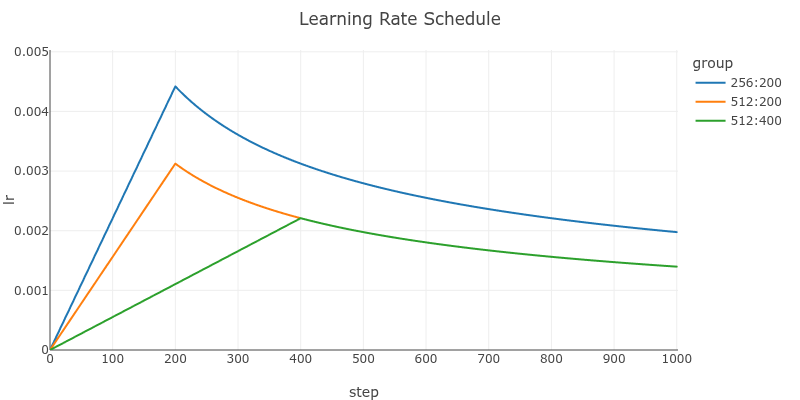

In [5]:
df1 = get_lr_curve(model_size=256, factor=1.0, warmup=200)
df2 = get_lr_curve(model_size=512, factor=1.0, warmup=200)
df3 = get_lr_curve(model_size=512, factor=1.0, warmup=400)
plot_lr_curve(pd.concat([df1, df2, df3]))

**Incoveniente del scheduler original:** $\;$ su dependencia del tamaño del modelo, lo que dificulta comparar modelos


<p style="page-break-after:always;"></p>


[**Cosine Annealing with Warmup:**](https://github.com/huggingface/transformers/blob/v4.56.0/src/transformers/optimization.py#L144) $\;$ scheduler actualmente popular que primero incrementa el learning rate linealmente, desde cero hasta un valor inicial prefijado, y luego lo decrementa hasta cero con base en la función coseno

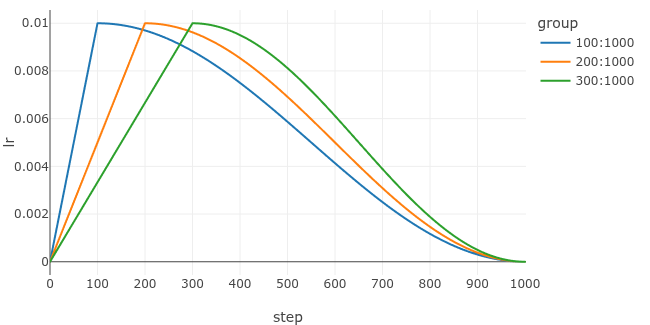

In [6]:
import import_ipynb; from at2523 import cosine_schedule_with_warmup
def get_lr_curve(num_warmup_steps, num_training_steps):
    dummy_model = torch.nn.Linear(1, 1); results = []; base_lr = 0.01; num_steps = 1001
    optimizer = torch.optim.AdamW(dummy_model.parameters(), lr=base_lr, betas=(0.9, 0.98), eps=1e-9)
    lr_scheduler = cosine_schedule_with_warmup(optimizer=optimizer,
        num_warmup_steps=num_warmup_steps, num_training_steps=num_training_steps)
    for step in range(num_steps):
        lr = optimizer.param_groups[0]["lr"]; optimizer.step(); lr_scheduler.step()
        results.append({'step': step, 'lr': lr, 'group': f"{num_warmup_steps}:{num_training_steps}"})
    return pd.DataFrame(results)
def plot_lr_curve(df):
    fig = px.line(df, x="step", y="lr", color="group", template='none')
    xaxis = dict(tickmode='linear', tick0=0, dtick=100, range=[0, 1002])
    width = 650; height = 325; margin = dict(l=50,r=50,t=10,b=50)
    fig.update_layout(width=width, height=height, xaxis=xaxis, margin=margin)
    fig.show(renderer="png", width=width, height=height)
df1 = get_lr_curve(100, 1000); df2 = get_lr_curve(200, 1000); df3 = get_lr_curve(300, 1000)
plot_lr_curve(pd.concat([df1, df2, df3]))


<p style="page-break-after:always;"></p>
